# ResFinder Database Exploration

This notebook explores the ResFinder database for AMR gene detection and resistance prediction.

**ResFinder** is a curated database of acquired antimicrobial resistance genes maintained by the Center for Genomic Epidemiology (CGE) at the Technical University of Denmark.

**Contents:**
1. Load and inspect raw ResFinder data
2. Analyze drug class distributions
3. Explore resistance mechanisms
4. Analyze antibiotic phenotypes
5. Explore sequence characteristics
6. Visualize processed features
7. Baseline model evaluation

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from Bio import SeqIO

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Paths
RESFINDER_DIR = Path('../data/raw/resfinder')
PROCESSED_DIR = Path('../data/processed/resfinder')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Raw ResFinder Data

In [2]:
# List available FASTA files (drug classes)
fasta_files = list(RESFINDER_DIR.glob('*.fsa'))
print(f"Number of FASTA files (drug classes): {len(fasta_files)}")
print("\nDrug class files:")
for f in sorted(fasta_files):
    if f.stem != 'all':  # Skip the combined file
        size_kb = f.stat().st_size / 1024
        print(f"  {f.stem}: {size_kb:.1f} KB")

Number of FASTA files (drug classes): 18

Drug class files:
  aminoglycoside: 196.5 KB
  beta-lactam: 1843.4 KB
  colistin: 178.1 KB
  fosfomycin: 18.3 KB
  fusidicacid: 2.0 KB
  glycopeptide: 54.0 KB
  macrolide: 170.1 KB
  misc: 2.5 KB
  nitroimidazole: 7.2 KB
  oxazolidinone: 42.8 KB
  phenicol: 65.9 KB
  pseudomonicacid: 9.2 KB
  quinolone: 90.3 KB
  rifampicin: 4.8 KB
  sulphonamide: 45.8 KB
  tetracycline: 254.3 KB
  trimethoprim: 51.8 KB


In [3]:
# Load phenotypes data
phenotypes_file = RESFINDER_DIR / 'phenotypes.txt'
phenotypes_df = pd.read_csv(phenotypes_file, sep='\t', dtype=str)

# Clean column names
phenotypes_df.columns = [col.strip().replace(' ', '_').lower() for col in phenotypes_df.columns]

print(f"Phenotypes records: {len(phenotypes_df)}")
print(f"Columns: {list(phenotypes_df.columns)}")

Phenotypes records: 3212
Columns: ['gene_accession_no.', 'class', 'phenotype', 'pmid', 'mechanism_of_resistance', 'notes', 'required_gene']


In [4]:
phenotypes_df.head(10)

,gene_accession_no.,class,phenotype,pmid,mechanism_of_resistance,notes,required_gene
0,ant(2'')-Ia_1_X04555,Aminoglycoside,"Gentamicin, Tobramycin",3024112,Enzymatic modification,Alternative name aadB,NaN
1,ant(2'')-Ia_10_HM367617,Aminoglycoside,"Gentamicin, Tobramycin",21873033,Enzymatic modification,NaN,NaN
2,ant(2'')-Ia_11_HM367620,Aminoglycoside,"Gentamicin, Tobramycin",21873033,Enzymatic modification,NaN,NaN
3,ant(2'')-Ia_12_HQ880250,Aminoglycoside,"Gentamicin, Tobramycin",unpublished,Enzymatic modification,NaN,NaN
4,ant(2'')-Ia_13_DQ176450,Aminoglycoside,"Gentamicin, Tobramycin",16304199,Enzymatic modification,NaN,NaN
5,ant(2'')-Ia_14_DQ266447,Aminoglycoside,"Gentamicin, Tobramycin",unpublished,Enzymatic modification,NaN,NaN
6,ant(2'')-Ia_15_EF205594,Aminoglycoside,"Gentamicin, Tobramycin",unpublished,Enzymatic modification,NaN,NaN
7,ant(2'')-Ia_16_HQ386848,Aminoglycoside,"Gentamicin, Tobramycin",unpublished,Enzymatic modification,NaN,NaN
8,ant(2'')-Ia_17_JTTZ01000034,Aminoglycoside,"Gentamicin, Tobramycin",unpublished,Enzymatic modification,NaN,NaN
9,ant(2'')-Ia_19_GQ466184,Aminoglycoside,"Gentamicin, Tobramycin",unpublished,Enzymatic modification,NaN,NaN


In [5]:
# Load all sequences and create gene index
genes = []
sequences = {}

for fasta_file in RESFINDER_DIR.glob('*.fsa'):
    if fasta_file.stem == 'all':
        continue
    
    drug_class = fasta_file.stem
    
    for record in SeqIO.parse(fasta_file, 'fasta'):
        parts = record.id.split('_')
        gene_name = parts[0] if parts else record.id
        
        genes.append({
            'gene_id': record.id,
            'gene_name': gene_name,
            'drug_class': drug_class,
            'sequence_length': len(record.seq),
            'description': record.description,
        })
        sequences[record.id] = str(record.seq)

genes_df = pd.DataFrame(genes)
print(f"Total genes loaded: {len(genes_df)}")
print(f"Unique gene names: {genes_df['gene_name'].nunique()}")

Total genes loaded: 3212
Unique gene names: 2601


In [6]:
# Merge with phenotype data
phenotypes_df_renamed = phenotypes_df.rename(columns={'gene_accession_no.': 'gene_id'})
genes_merged = genes_df.merge(phenotypes_df_renamed, on='gene_id', how='left')

print(f"Genes with phenotype info: {genes_merged['phenotype'].notna().sum()}")
print(f"Genes with mechanism info: {genes_merged['mechanism_of_resistance'].notna().sum()}")

Genes with phenotype info: 3212
Genes with mechanism info: 3210


In [7]:
# Basic statistics
print("=== ResFinder Database Statistics ===")
print(f"Total resistance genes: {len(genes_df):,}")
print(f"Unique gene names: {genes_df['gene_name'].nunique():,}")
print(f"Drug classes: {genes_df['drug_class'].nunique()}")
print(f"\nSequence length statistics:")
print(f"  Min: {genes_df['sequence_length'].min()} bp")
print(f"  Max: {genes_df['sequence_length'].max()} bp")
print(f"  Mean: {genes_df['sequence_length'].mean():.0f} bp")
print(f"  Median: {genes_df['sequence_length'].median():.0f} bp")

=== ResFinder Database Statistics ===
Total resistance genes: 3,212
Unique gene names: 2,601
Drug classes: 17

Sequence length statistics:
  Min: 237 bp
  Max: 3153 bp
  Mean: 931 bp
  Median: 861 bp


## 2. Drug Class Distribution

In [8]:
# Drug class statistics
drug_class_stats = genes_df.groupby('drug_class').agg(
    gene_count=('gene_id', 'count'),
    unique_genes=('gene_name', 'nunique'),
    mean_length=('sequence_length', 'mean'),
    min_length=('sequence_length', 'min'),
    max_length=('sequence_length', 'max'),
).reset_index().sort_values('gene_count', ascending=False)

print("Drug Class Statistics:")
drug_class_stats

Drug Class Statistics:


,drug_class,gene_count,unique_genes,mean_length,min_length,max_length
1,beta-lactam,2031,1850,891.656819,407,2037
0,aminoglycoside,264,179,727.681818,348,1476
6,macrolide,174,102,965.741379,417,1710
15,tetracycline,162,84,1561.444444,327,3135
12,quinolone,125,122,707.736000,645,3153
16,trimethoprim,109,44,460.706422,237,588
2,colistin,109,107,1626.633028,1407,1698
10,phenicol,66,45,988.090909,537,1428
14,sulphonamide,54,4,834.944444,792,882
3,fosfomycin,40,27,441.825000,357,993


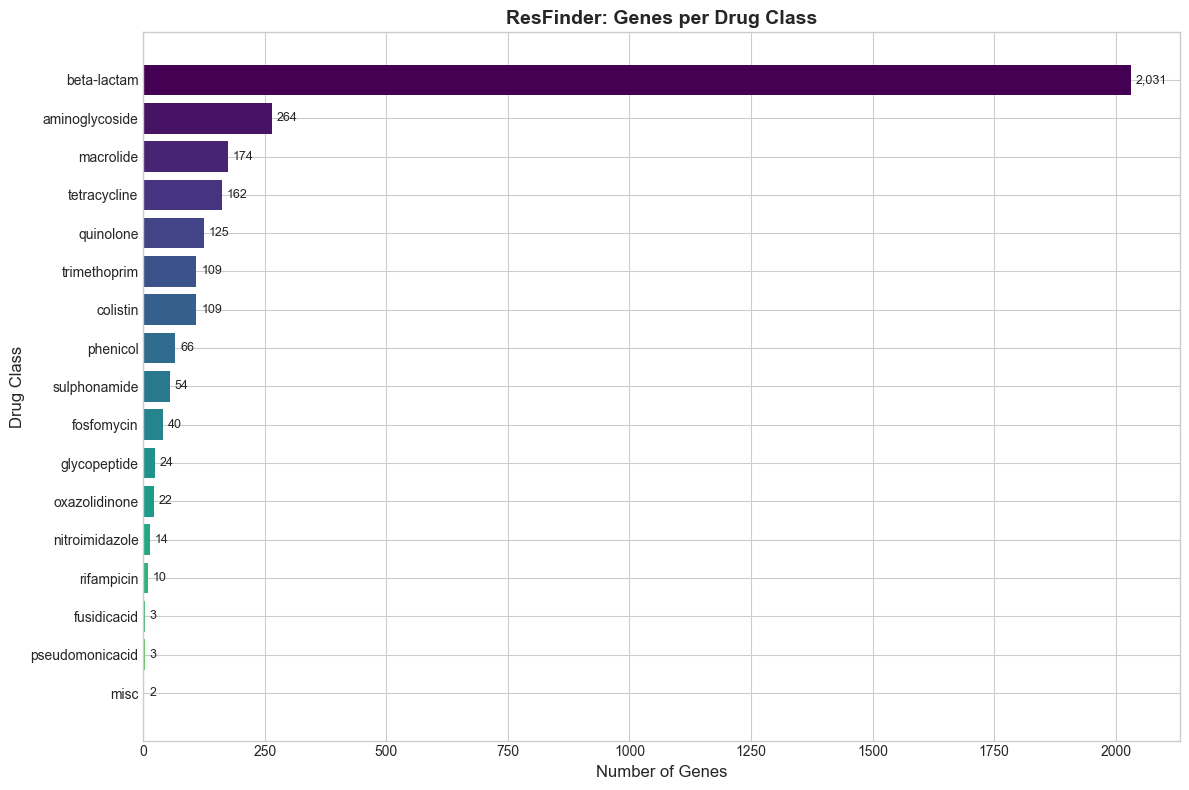

In [9]:
# Visualize drug class distribution
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.viridis(np.linspace(0, 0.8, len(drug_class_stats)))

bars = ax.barh(range(len(drug_class_stats)), drug_class_stats['gene_count'], color=colors)
ax.set_yticks(range(len(drug_class_stats)))
ax.set_yticklabels(drug_class_stats['drug_class'])
ax.set_xlabel('Number of Genes', fontsize=12)
ax.set_ylabel('Drug Class', fontsize=12)
ax.set_title('ResFinder: Genes per Drug Class', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add count labels
for bar, count in zip(bars, drug_class_stats['gene_count']):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

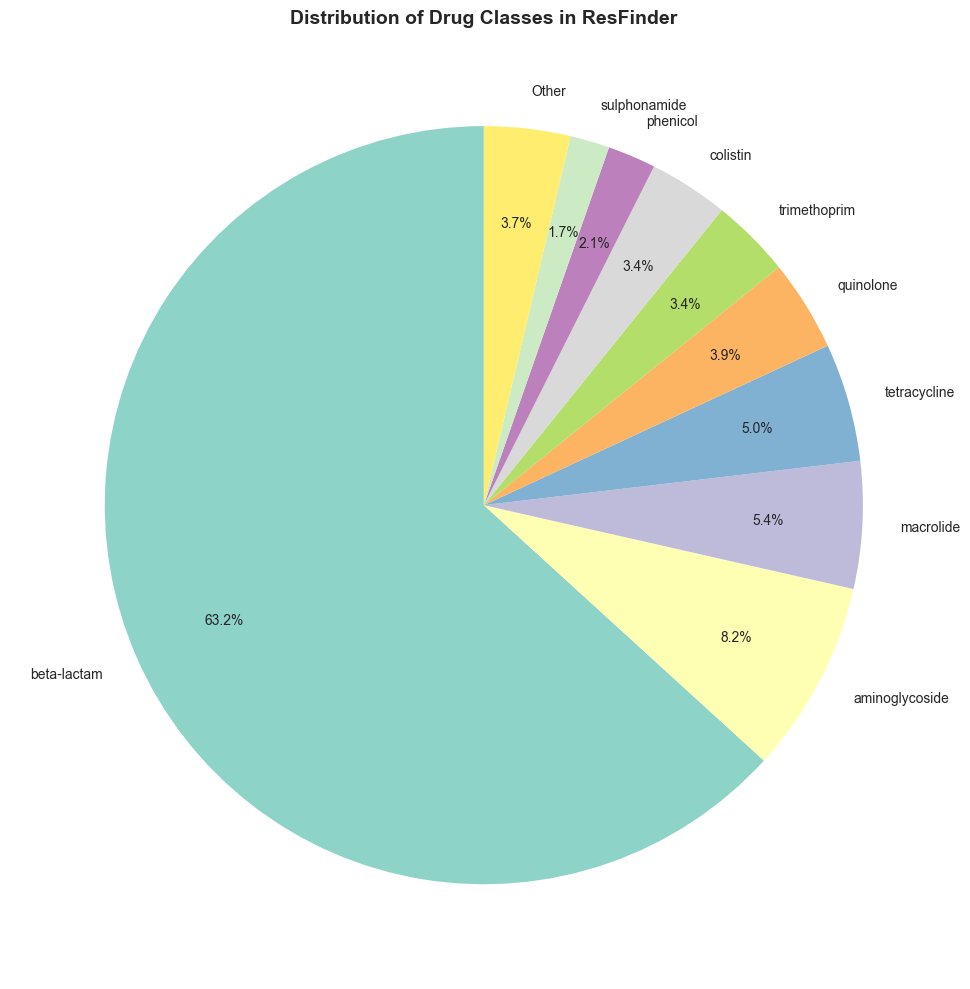

In [10]:
# Pie chart of drug class distribution
fig, ax = plt.subplots(figsize=(10, 10))

# Group small classes into "Other"
threshold = 50
major_classes = drug_class_stats[drug_class_stats['gene_count'] >= threshold].copy()
other_count = drug_class_stats[drug_class_stats['gene_count'] < threshold]['gene_count'].sum()

if other_count > 0:
    other_row = pd.DataFrame([{'drug_class': 'Other', 'gene_count': other_count}])
    plot_data = pd.concat([major_classes[['drug_class', 'gene_count']], other_row])
else:
    plot_data = major_classes[['drug_class', 'gene_count']]

colors = plt.cm.Set3(np.linspace(0, 1, len(plot_data)))
wedges, texts, autotexts = ax.pie(
    plot_data['gene_count'],
    labels=plot_data['drug_class'],
    autopct='%1.1f%%',
    colors=colors,
    pctdistance=0.75,
    startangle=90
)
ax.set_title('Distribution of Drug Classes in ResFinder', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Resistance Mechanism Analysis

In [11]:
# Resistance mechanism distribution
mechanism_counts = genes_merged['mechanism_of_resistance'].value_counts()
print(f"Unique resistance mechanisms: {len(mechanism_counts)}")
print("\nMechanism Distribution:")
mechanism_counts

Unique resistance mechanisms: 27

Mechanism Distribution:


mechanism_of_resistance
Enzymatic inactivation                                                                                                                                                                       2152
Enzymatic modification                                                                                                                                                                        259
Target protection                                                                                                                                                                             254
Target modification                                                                                                                                                                           240
Purine synthesis                                                                                                                                                                              163
Increa

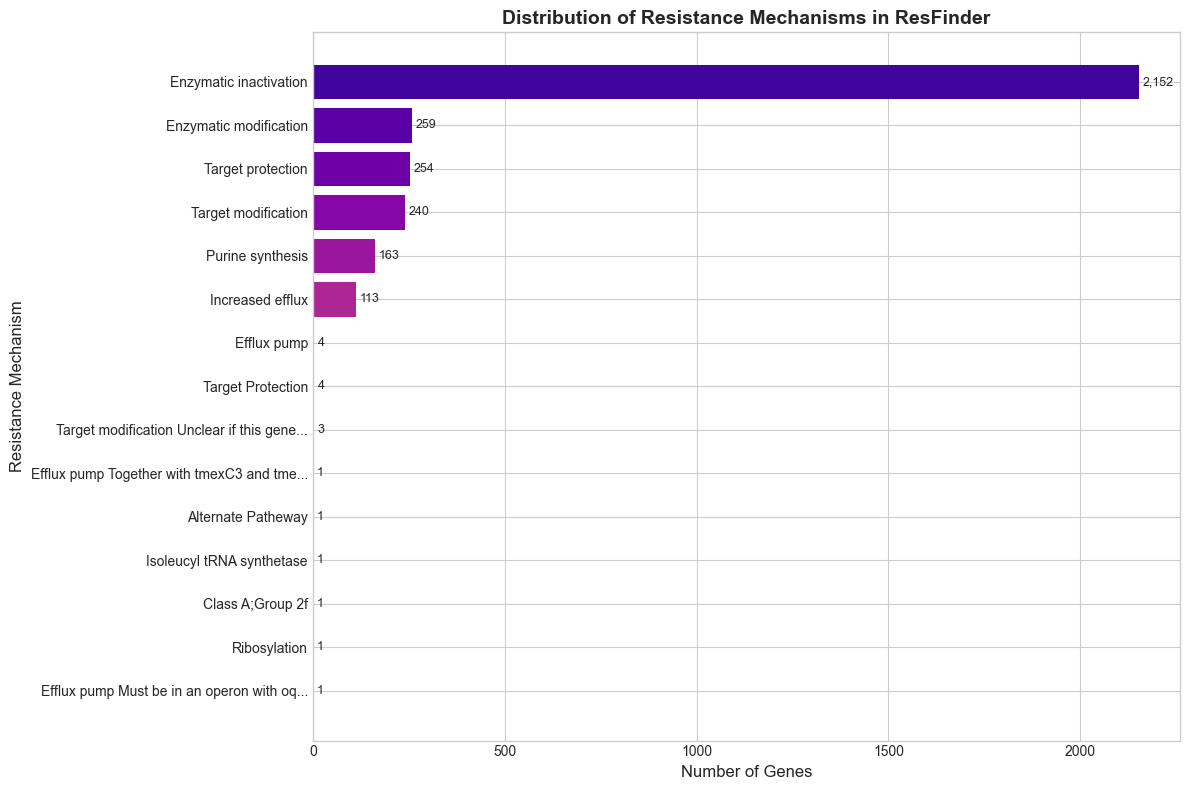

In [12]:
# Visualize resistance mechanisms
fig, ax = plt.subplots(figsize=(12, 8))

# Take top 15 mechanisms
top_mechanisms = mechanism_counts.head(15)

colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(top_mechanisms)))
bars = ax.barh(range(len(top_mechanisms)), top_mechanisms.values, color=colors)
ax.set_yticks(range(len(top_mechanisms)))
ax.set_yticklabels([m[:40] + '...' if len(str(m)) > 40 else m for m in top_mechanisms.index])
ax.set_xlabel('Number of Genes', fontsize=12)
ax.set_ylabel('Resistance Mechanism', fontsize=12)
ax.set_title('Distribution of Resistance Mechanisms in ResFinder', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add count labels
for bar, count in zip(bars, top_mechanisms.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

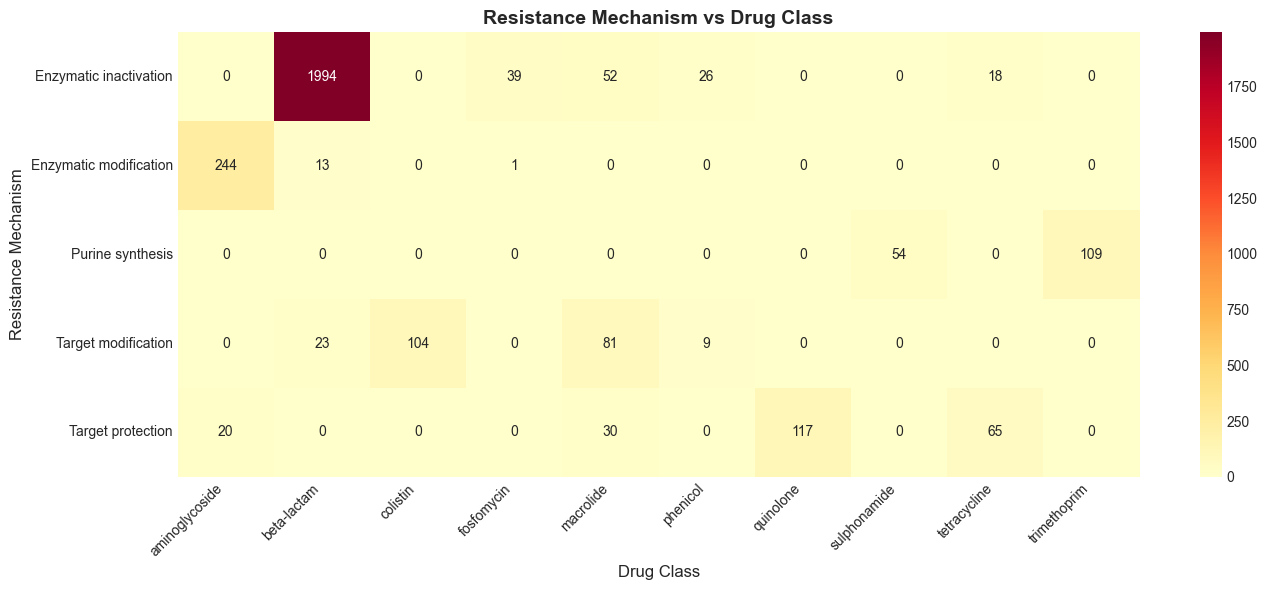

In [13]:
# Mechanism vs Drug Class heatmap
# Get top mechanisms and drug classes
top_5_mechanisms = mechanism_counts.head(5).index.tolist()
top_10_drug_classes = drug_class_stats.head(10)['drug_class'].tolist()

# Filter data
filtered = genes_merged[
    (genes_merged['mechanism_of_resistance'].isin(top_5_mechanisms)) &
    (genes_merged['drug_class'].isin(top_10_drug_classes))
]

# Create crosstab
crosstab = pd.crosstab(filtered['mechanism_of_resistance'], filtered['drug_class'])

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Resistance Mechanism vs Drug Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Drug Class', fontsize=12)
ax.set_ylabel('Resistance Mechanism', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Antibiotic Phenotype Analysis

In [14]:
# Parse antibiotics from phenotype field (comma-separated)
antibiotic_counts = Counter()
for phenotype in genes_merged['phenotype'].dropna():
    for ab in str(phenotype).split(','):
        ab = ab.strip()
        if ab:
            antibiotic_counts[ab] += 1

antibiotic_df = pd.DataFrame([
    {'antibiotic': ab, 'gene_count': count}
    for ab, count in antibiotic_counts.most_common()
])

print(f"Unique antibiotics in phenotype data: {len(antibiotic_df)}")
print("\nTop 25 antibiotics:")
antibiotic_df.head(25)

Unique antibiotics in phenotype data: 92

Top 25 antibiotics:


,antibiotic,gene_count
0,Ampicillin,1339
1,Amoxicillin,1336
2,Piperacillin,1225
3,Ceftazidime,938
4,Cefotaxime,863
5,Ticarcillin,795
6,Unknown Beta-lactam,674
7,Ampicillin+Clavulanic acid,636
8,Amoxicillin+Clavulanic acid,635
9,Cefepime,615


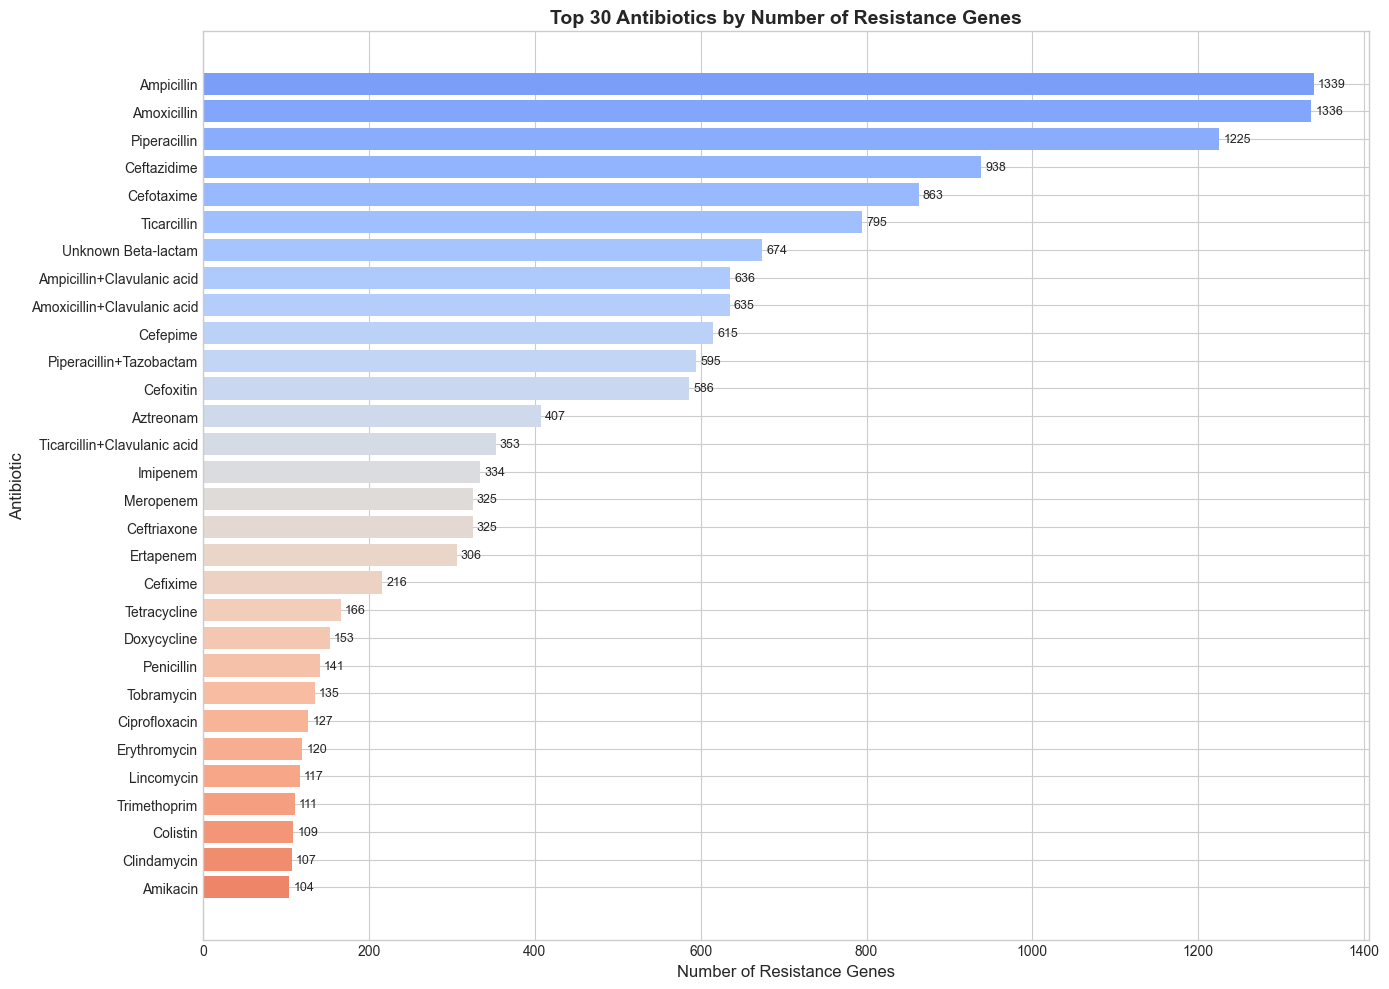

In [15]:
# Visualize antibiotic distribution
fig, ax = plt.subplots(figsize=(14, 10))

top_antibiotics = antibiotic_df.head(30)
colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(top_antibiotics)))

bars = ax.barh(range(len(top_antibiotics)), top_antibiotics['gene_count'], color=colors)
ax.set_yticks(range(len(top_antibiotics)))
ax.set_yticklabels(top_antibiotics['antibiotic'])
ax.set_xlabel('Number of Resistance Genes', fontsize=12)
ax.set_ylabel('Antibiotic', fontsize=12)
ax.set_title('Top 30 Antibiotics by Number of Resistance Genes', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add count labels
for bar, count in zip(bars, top_antibiotics['gene_count']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{count}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Average antibiotics per gene: 4.81
Max antibiotics per gene: 17
Genes with single antibiotic: 1292
Genes with multiple antibiotics: 1920


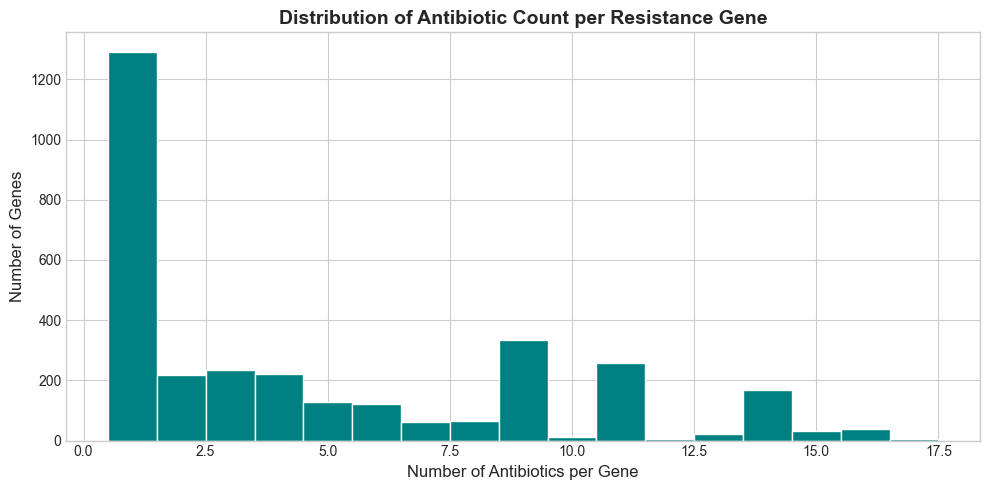

In [16]:
# Multi-label statistics: how many antibiotics per gene?
genes_merged['n_antibiotics'] = genes_merged['phenotype'].apply(
    lambda x: len([ab for ab in str(x).split(',') if ab.strip()]) if pd.notna(x) else 0
)

fig, ax = plt.subplots(figsize=(10, 5))
ab_counts = genes_merged[genes_merged['n_antibiotics'] > 0]['n_antibiotics']
ax.hist(ab_counts, bins=range(1, ab_counts.max() + 2), color='teal', edgecolor='white', align='left')
ax.set_xlabel('Number of Antibiotics per Gene', fontsize=12)
ax.set_ylabel('Number of Genes', fontsize=12)
ax.set_title('Distribution of Antibiotic Count per Resistance Gene', fontsize=14, fontweight='bold')

print(f"Average antibiotics per gene: {ab_counts.mean():.2f}")
print(f"Max antibiotics per gene: {ab_counts.max()}")
print(f"Genes with single antibiotic: {(ab_counts == 1).sum()}")
print(f"Genes with multiple antibiotics: {(ab_counts > 1).sum()}")

plt.tight_layout()
plt.show()

## 5. Gene Family Analysis

In [17]:
# Gene name distribution
gene_name_counts = genes_df['gene_name'].value_counts()
print(f"Unique gene names: {len(gene_name_counts)}")
print("\nTop 20 gene names (by variant count):")
gene_name_counts.head(20)

Unique gene names: 2601

Top 20 gene names (by variant count):


gene_name
blaZ           137
sul1            33
optrA           20
ant(2'')-Ia     19
sul2            19
dfrA1           17
erm(B)          14
tet(M)          13
dfrA17          11
aph(3')-Ia      10
FloR            10
erm(C)          10
dfrA12          10
mecA             9
tet(L)           9
vat(E)           7
VanHDX           7
fosA             7
aac(3)-IIa       6
ere(A)           6
Name: count, dtype: int64

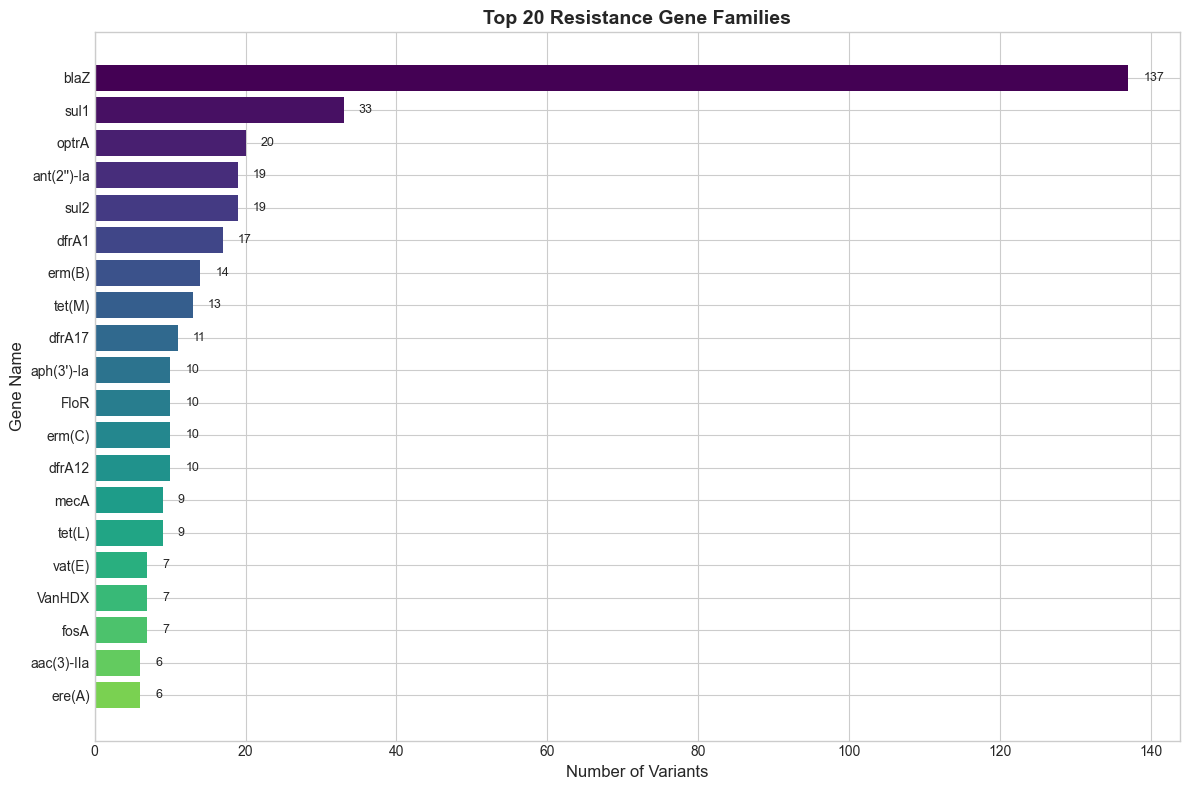

In [18]:
# Visualize top gene families
fig, ax = plt.subplots(figsize=(12, 8))

top_genes = gene_name_counts.head(20)
colors = plt.cm.viridis(np.linspace(0, 0.8, len(top_genes)))

bars = ax.barh(range(len(top_genes)), top_genes.values, color=colors)
ax.set_yticks(range(len(top_genes)))
ax.set_yticklabels(top_genes.index)
ax.set_xlabel('Number of Variants', fontsize=12)
ax.set_ylabel('Gene Name', fontsize=12)
ax.set_title('Top 20 Resistance Gene Families', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add count labels
for bar, count in zip(bars, top_genes.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{count}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Sequence Characteristics

In [19]:
# Calculate GC content for all sequences
def compute_gc_content(seq):
    seq = seq.upper()
    if len(seq) == 0:
        return 0
    return (seq.count('G') + seq.count('C')) / len(seq)

genes_df['gc_content'] = [compute_gc_content(sequences[gid]) for gid in genes_df['gene_id']]

print("GC Content Statistics:")
print(genes_df['gc_content'].describe())

GC Content Statistics:
count    3212.000000
mean        0.480582
std         0.117881
min         0.226098
25%         0.390303
50%         0.490128
75%         0.566536
max         0.770115
Name: gc_content, dtype: float64


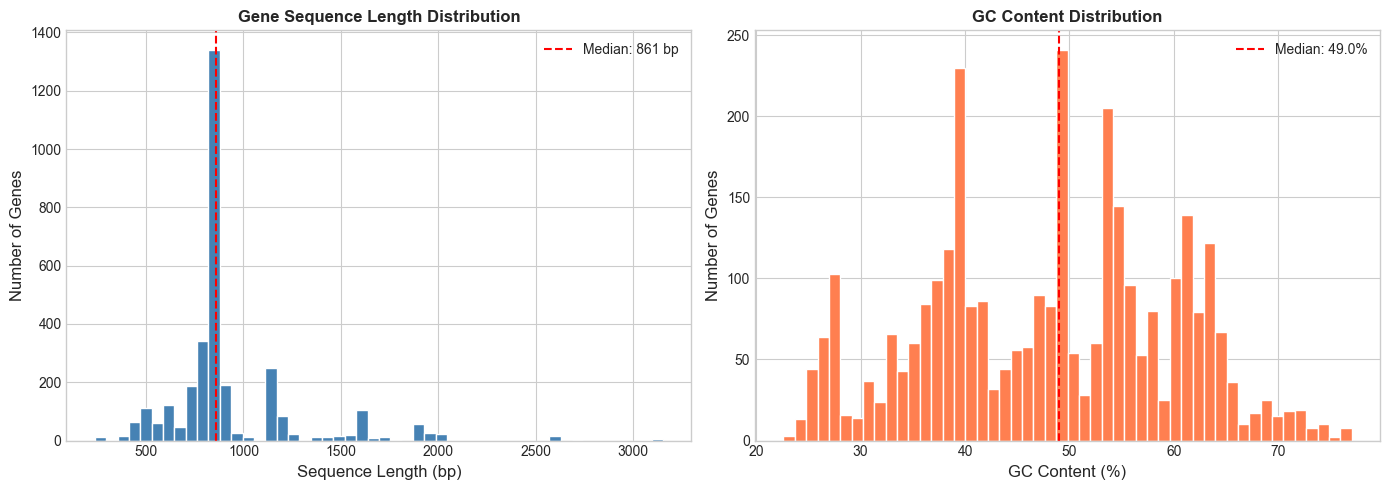

In [20]:
# Sequence length and GC content distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sequence length histogram
axes[0].hist(genes_df['sequence_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Sequence Length (bp)', fontsize=12)
axes[0].set_ylabel('Number of Genes', fontsize=12)
axes[0].set_title('Gene Sequence Length Distribution', fontsize=12, fontweight='bold')
axes[0].axvline(genes_df['sequence_length'].median(), color='red', linestyle='--', 
               label=f'Median: {genes_df["sequence_length"].median():.0f} bp')
axes[0].legend()

# GC content histogram
axes[1].hist(genes_df['gc_content'] * 100, bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('GC Content (%)', fontsize=12)
axes[1].set_ylabel('Number of Genes', fontsize=12)
axes[1].set_title('GC Content Distribution', fontsize=12, fontweight='bold')
axes[1].axvline(genes_df['gc_content'].median() * 100, color='red', linestyle='--',
               label=f'Median: {genes_df["gc_content"].median()*100:.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

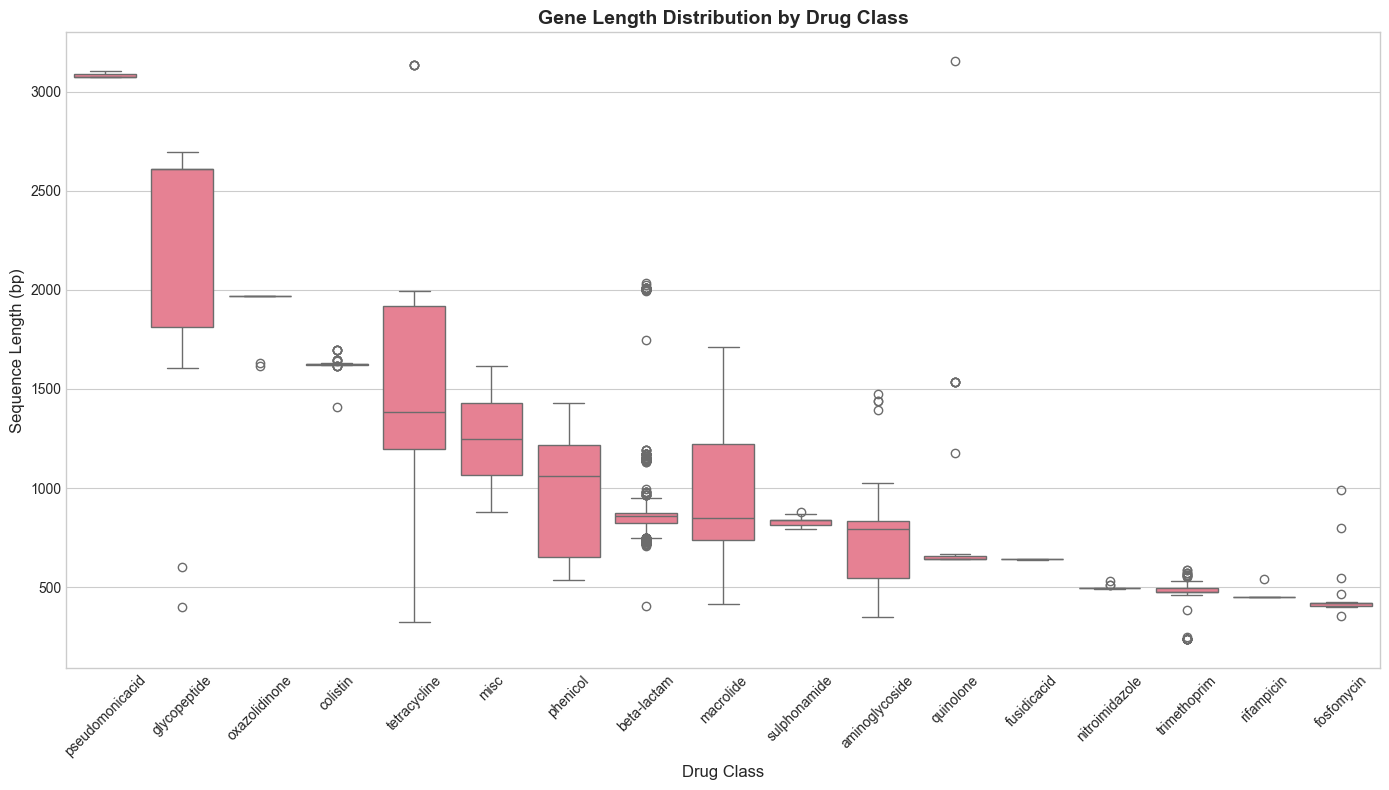

In [21]:
# Sequence length by drug class
fig, ax = plt.subplots(figsize=(14, 8))

# Order by median length
order = genes_df.groupby('drug_class')['sequence_length'].median().sort_values(ascending=False).index

sns.boxplot(data=genes_df, x='drug_class', y='sequence_length', order=order, ax=ax)
ax.set_xlabel('Drug Class', fontsize=12)
ax.set_ylabel('Sequence Length (bp)', fontsize=12)
ax.set_title('Gene Length Distribution by Drug Class', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

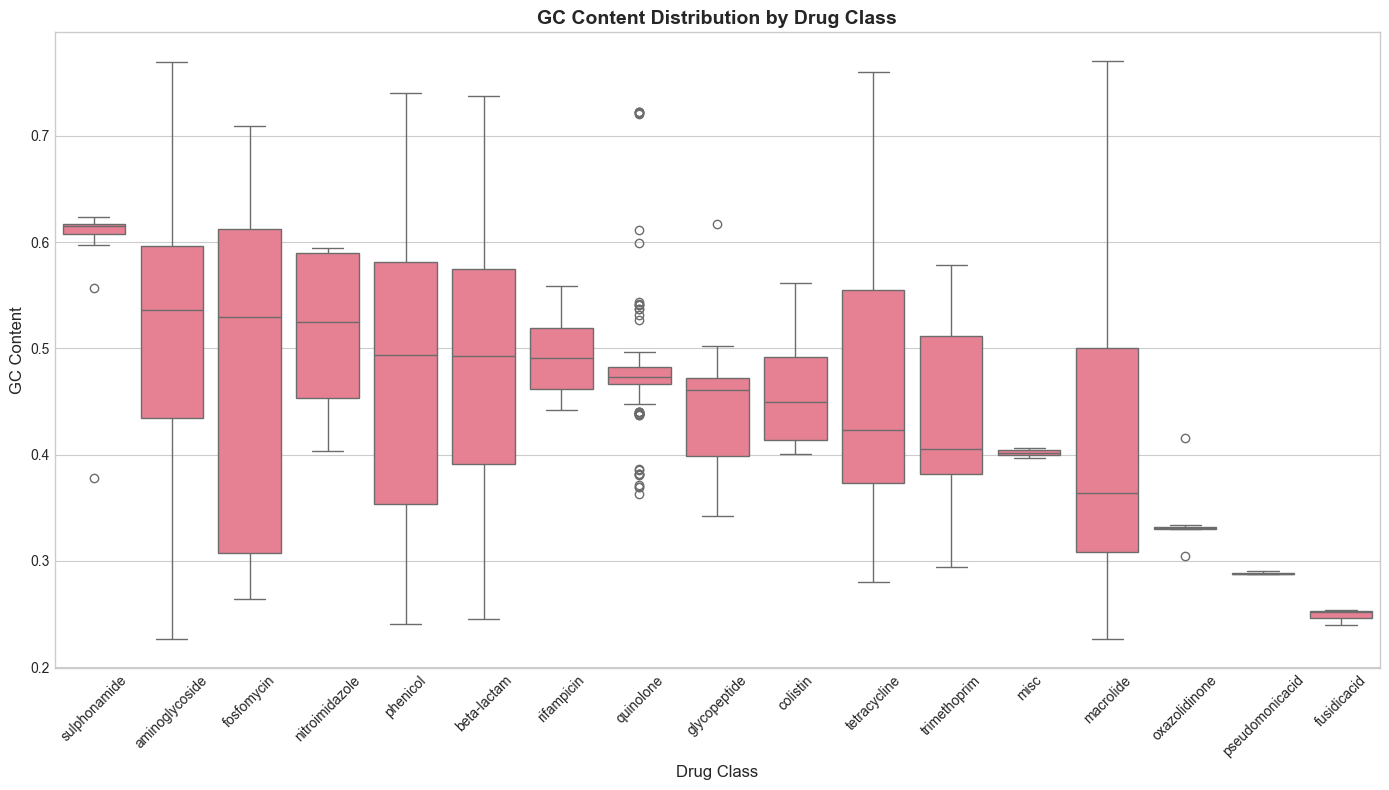

In [22]:
# GC content by drug class
fig, ax = plt.subplots(figsize=(14, 8))

# Order by median GC
order = genes_df.groupby('drug_class')['gc_content'].median().sort_values(ascending=False).index

sns.boxplot(data=genes_df, x='drug_class', y='gc_content', order=order, ax=ax)
ax.set_xlabel('Drug Class', fontsize=12)
ax.set_ylabel('GC Content', fontsize=12)
ax.set_title('GC Content Distribution by Drug Class', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

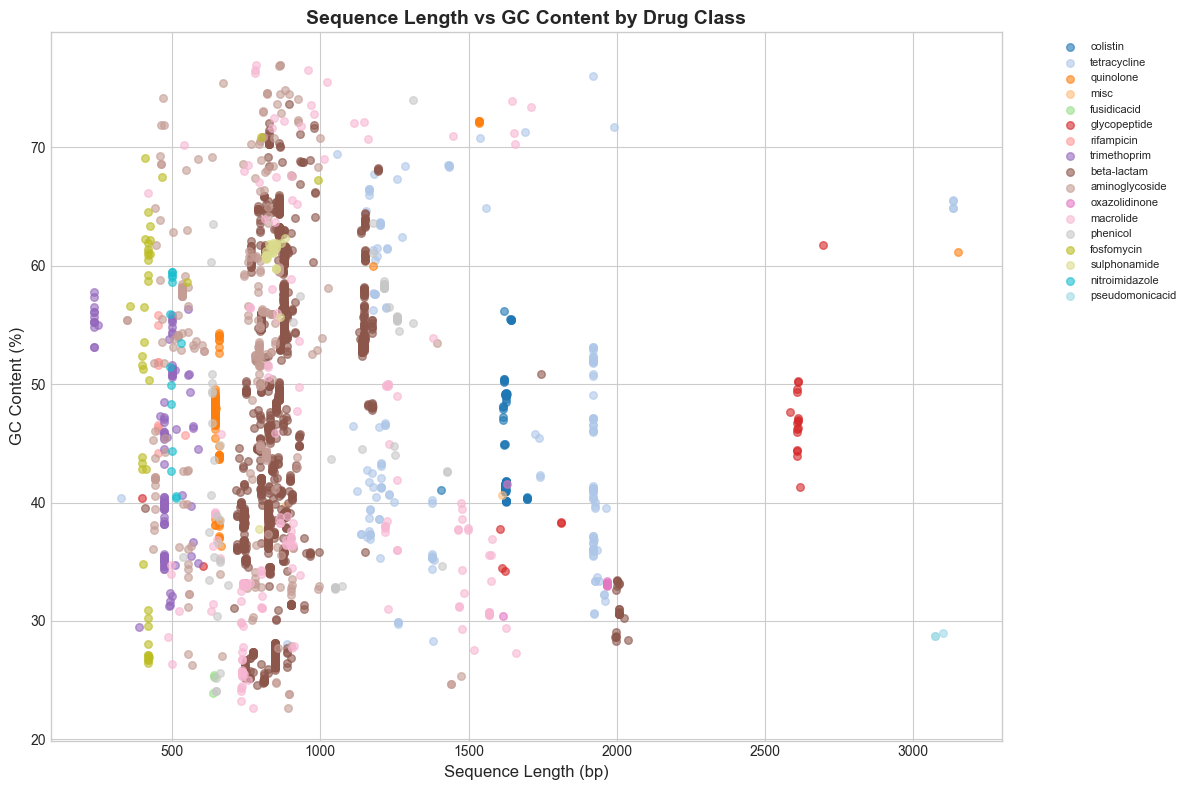

In [23]:
# Scatter plot: Length vs GC content
fig, ax = plt.subplots(figsize=(12, 8))

# Color by drug class
drug_classes = genes_df['drug_class'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(drug_classes)))
color_map = dict(zip(drug_classes, colors))

for dc in drug_classes:
    mask = genes_df['drug_class'] == dc
    ax.scatter(genes_df[mask]['sequence_length'], genes_df[mask]['gc_content'] * 100,
               c=[color_map[dc]], label=dc, alpha=0.6, s=30)

ax.set_xlabel('Sequence Length (bp)', fontsize=12)
ax.set_ylabel('GC Content (%)', fontsize=12)
ax.set_title('Sequence Length vs GC Content by Drug Class', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 7. Processed Features Exploration

In [24]:
# Load processed drug class data
X_train = np.load(PROCESSED_DIR / 'resfinder_drug_class_X_train.npy')
X_val = np.load(PROCESSED_DIR / 'resfinder_drug_class_X_val.npy')
X_test = np.load(PROCESSED_DIR / 'resfinder_drug_class_X_test.npy')
y_train = np.load(PROCESSED_DIR / 'resfinder_drug_class_y_train.npy')
y_val = np.load(PROCESSED_DIR / 'resfinder_drug_class_y_val.npy')
y_test = np.load(PROCESSED_DIR / 'resfinder_drug_class_y_test.npy')

with open(PROCESSED_DIR / 'resfinder_drug_class_metadata.json') as f:
    metadata = json.load(f)

print("=== Processed Drug Class Data ===")
print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features (k-mers): {X_train.shape[1]}")
print(f"Number of classes: {len(metadata['class_names'])}")
print(f"Classes: {metadata['class_names']}")

=== Processed Drug Class Data ===
Training samples: 2226
Validation samples: 318
Test samples: 636
Number of features (k-mers): 500
Number of classes: 12
Classes: ['aminoglycoside', 'beta-lactam', 'colistin', 'fosfomycin', 'glycopeptide', 'macrolide', 'oxazolidinone', 'phenicol', 'quinolone', 'sulphonamide', 'tetracycline', 'trimethoprim']


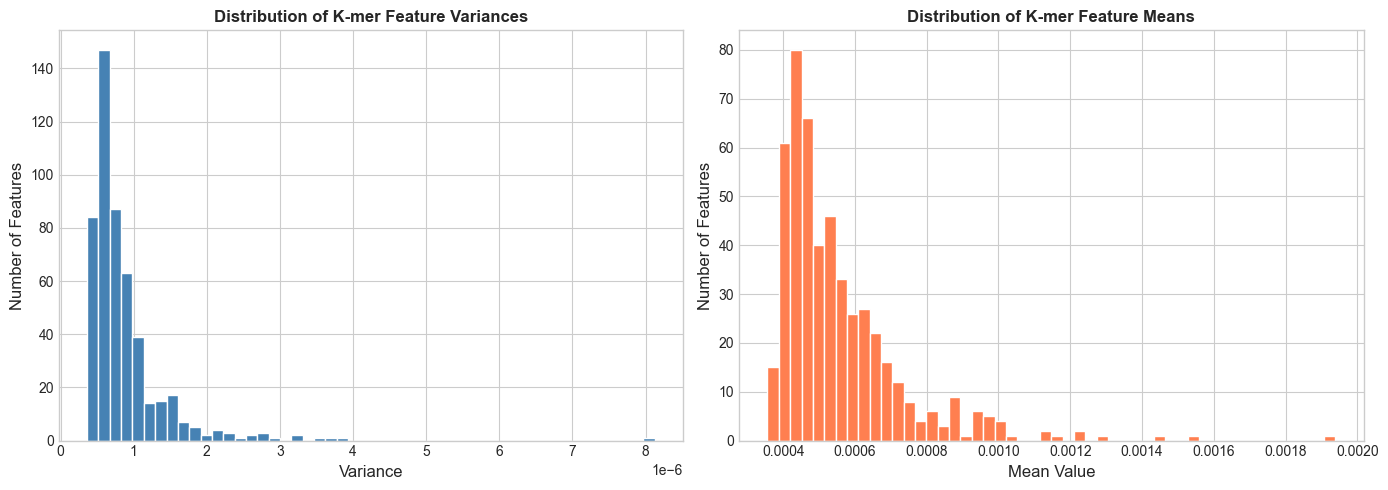

In [25]:
# Feature distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature variance
feature_var = np.var(X_train, axis=0)
axes[0].hist(feature_var, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Variance', fontsize=12)
axes[0].set_ylabel('Number of Features', fontsize=12)
axes[0].set_title('Distribution of K-mer Feature Variances', fontsize=12, fontweight='bold')

# Feature means
feature_mean = np.mean(X_train, axis=0)
axes[1].hist(feature_mean, bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('Mean Value', fontsize=12)
axes[1].set_ylabel('Number of Features', fontsize=12)
axes[1].set_title('Distribution of K-mer Feature Means', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

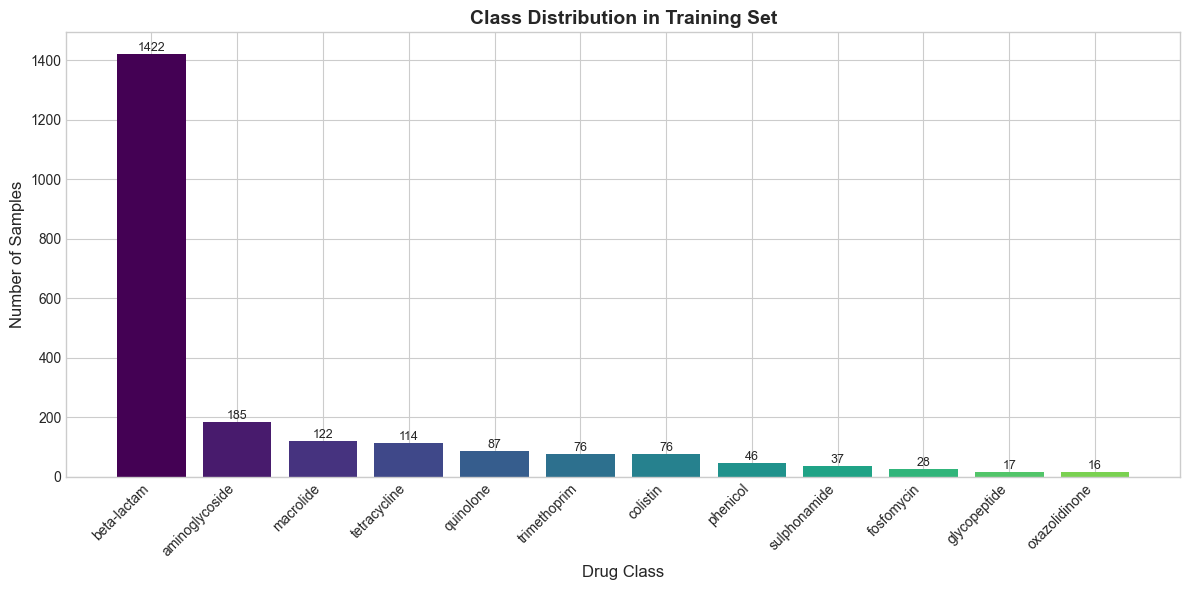

In [26]:
# Class distribution in training set
class_names = metadata['class_names']
class_counts = np.bincount(y_train)

fig, ax = plt.subplots(figsize=(12, 6))

sorted_idx = np.argsort(class_counts)[::-1]
colors = plt.cm.viridis(np.linspace(0, 0.8, len(class_names)))

bars = ax.bar(range(len(class_names)), class_counts[sorted_idx], color=colors)
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels([class_names[i] for i in sorted_idx], rotation=45, ha='right')
ax.set_xlabel('Drug Class', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Class Distribution in Training Set', fontsize=14, fontweight='bold')

# Add count labels
for bar, count in zip(bars, class_counts[sorted_idx]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{count}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Dimensionality Reduction

In [27]:
from sklearn.decomposition import PCA

# PCA visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

PCA explained variance ratio: [0.22969042 0.07953495]
Total variance explained: 30.92%


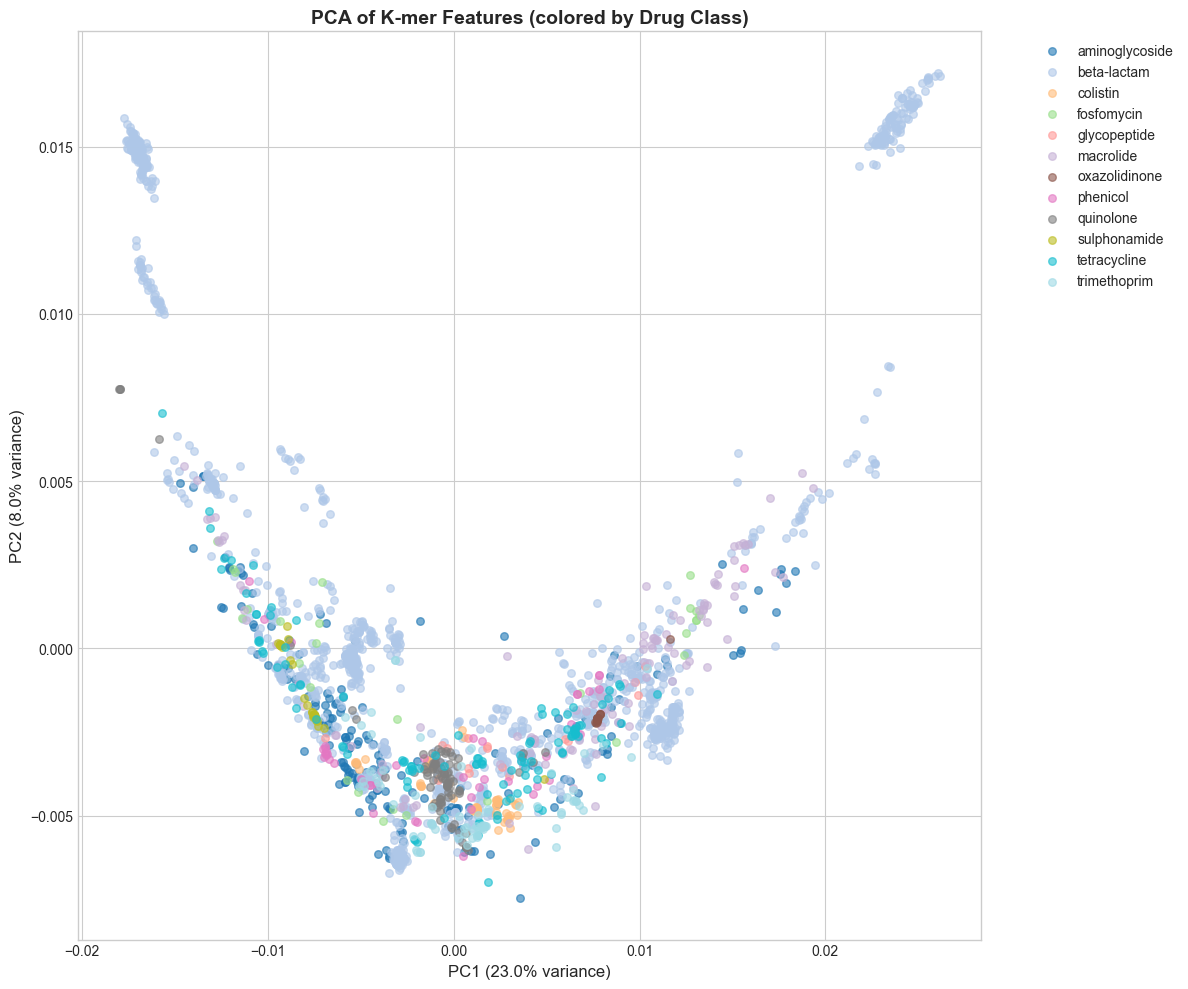

In [28]:
# PCA colored by drug class
fig, ax = plt.subplots(figsize=(12, 10))

colors = plt.cm.tab20(np.linspace(0, 1, len(class_names)))

for i, class_name in enumerate(class_names):
    mask = y_train == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[i]], label=class_name, alpha=0.6, s=30)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('PCA of K-mer Features (colored by Drug Class)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 9. Baseline Model Evaluation

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

print("Training baseline Random Forest model...")
print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training baseline Random Forest model...
Training samples: 2226
Validation samples: 318
Test samples: 636


In [30]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [31]:
# Evaluate on validation set
y_val_pred = rf.predict(X_val)

print("=== Validation Set Performance ===")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Macro F1: {f1_score(y_val, y_val_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_val, y_val_pred, average='weighted'):.4f}")

=== Validation Set Performance ===
Accuracy: 0.9119
Macro F1: 0.8256
Weighted F1: 0.9047


In [32]:
# Evaluate on test set
y_test_pred = rf.predict(X_test)

print("=== Test Set Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Macro F1: {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_names))

=== Test Set Performance ===
Accuracy: 0.9167
Macro F1: 0.8305
Weighted F1: 0.9067

Classification Report:
                precision    recall  f1-score   support

aminoglycoside       0.87      0.74      0.80        53
   beta-lactam       0.91      1.00      0.95       406
      colistin       1.00      1.00      1.00        22
    fosfomycin       1.00      0.25      0.40         8
  glycopeptide       1.00      0.80      0.89         5
     macrolide       0.83      0.54      0.66        35
 oxazolidinone       1.00      1.00      1.00         4
      phenicol       1.00      0.31      0.47        13
     quinolone       1.00      0.96      0.98        25
  sulphonamide       1.00      1.00      1.00        11
  tetracycline       0.91      0.94      0.92        32
  trimethoprim       1.00      0.82      0.90        22

      accuracy                           0.92       636
     macro avg       0.96      0.78      0.83       636
  weighted avg       0.92      0.92      0.91      

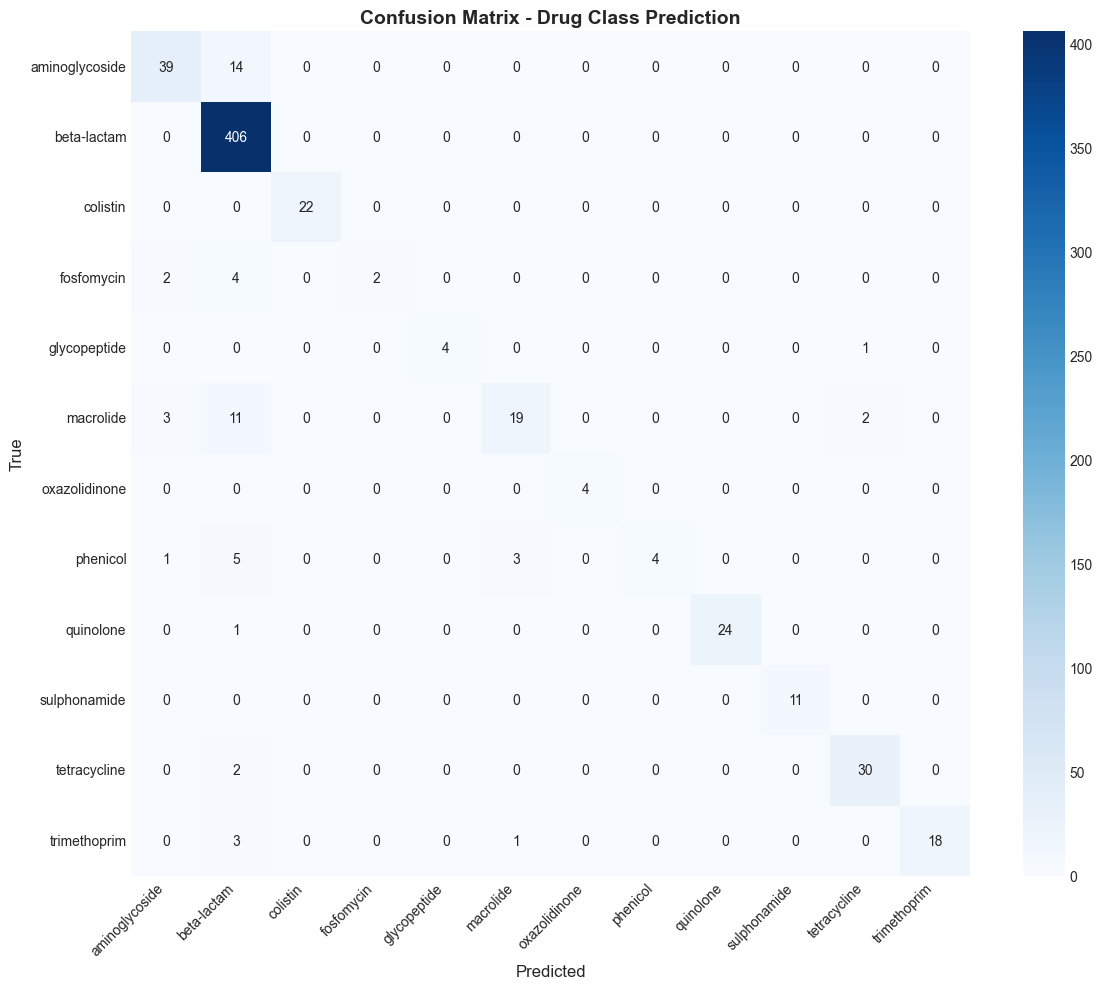

In [33]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix - Drug Class Prediction', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

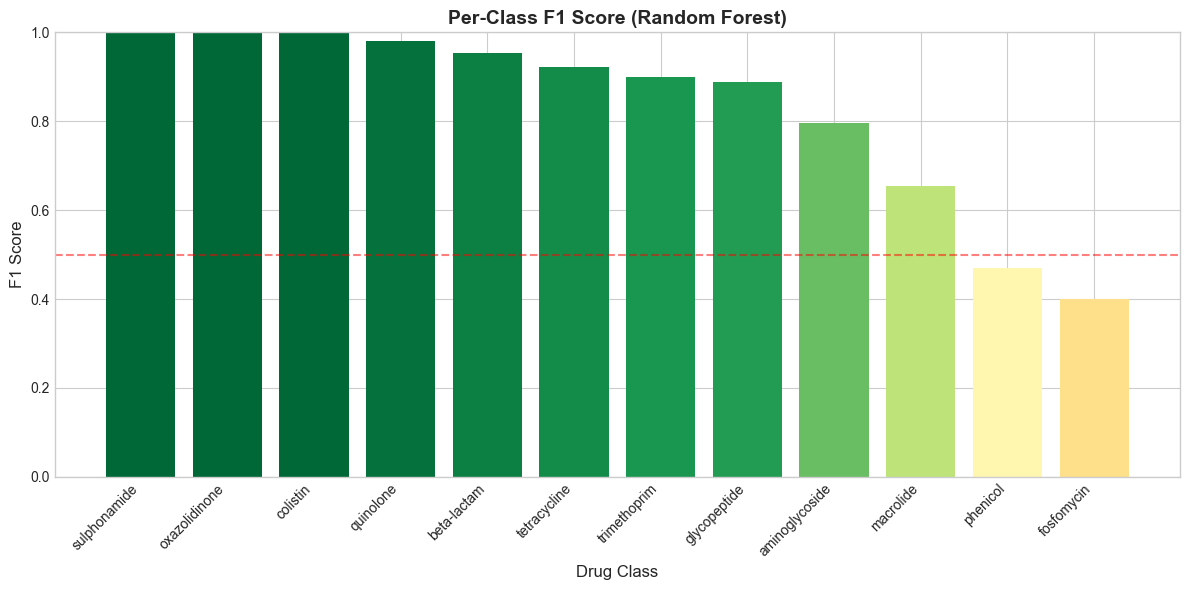

In [34]:
# Per-class F1 scores
per_class_f1 = f1_score(y_test, y_test_pred, average=None)

fig, ax = plt.subplots(figsize=(12, 6))

sorted_idx = np.argsort(per_class_f1)[::-1]
colors = plt.cm.RdYlGn(per_class_f1[sorted_idx])

bars = ax.bar(range(len(class_names)), per_class_f1[sorted_idx], color=colors)
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels([class_names[i] for i in sorted_idx], rotation=45, ha='right')
ax.set_xlabel('Drug Class', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Per-Class F1 Score (Random Forest)', fontsize=14, fontweight='bold')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 10. Mechanism Prediction Evaluation

In [35]:
# Load mechanism data
X_mech_train = np.load(PROCESSED_DIR / 'resfinder_mechanism_X_train.npy')
X_mech_test = np.load(PROCESSED_DIR / 'resfinder_mechanism_X_test.npy')
y_mech_train = np.load(PROCESSED_DIR / 'resfinder_mechanism_y_train.npy')
y_mech_test = np.load(PROCESSED_DIR / 'resfinder_mechanism_y_test.npy')

with open(PROCESSED_DIR / 'resfinder_mechanism_metadata.json') as f:
    mech_metadata = json.load(f)

mech_classes = mech_metadata['class_names']
print(f"Mechanisms: {mech_classes}")

Mechanisms: ['Enzymatic inactivation', 'Enzymatic modification', 'Increased efflux', 'Purine synthesis', 'Target modification', 'Target protection']


In [36]:
# Train and evaluate
rf_mech = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_mech.fit(X_mech_train, y_mech_train)

y_mech_pred = rf_mech.predict(X_mech_test)

print("=== Mechanism Prediction Performance ===")
print(f"Accuracy: {accuracy_score(y_mech_test, y_mech_pred):.4f}")
print(f"Macro F1: {f1_score(y_mech_test, y_mech_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_mech_test, y_mech_pred, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_mech_test, y_mech_pred, target_names=mech_classes))

=== Mechanism Prediction Performance ===
Accuracy: 0.9262
Macro F1: 0.8781
Weighted F1: 0.9225

Classification Report:
                        precision    recall  f1-score   support

Enzymatic inactivation       0.90      1.00      0.95       431
Enzymatic modification       1.00      0.69      0.82        52
      Increased efflux       1.00      0.64      0.78        22
      Purine synthesis       1.00      0.91      0.95        33
   Target modification       1.00      0.75      0.86        48
     Target protection       1.00      0.84      0.91        51

              accuracy                           0.93       637
             macro avg       0.98      0.81      0.88       637
          weighted avg       0.93      0.93      0.92       637



## 11. Multi-label Antibiotic Prediction

In [37]:
# Load antibiotic data
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import hamming_loss

X_ab_train = np.load(PROCESSED_DIR / 'resfinder_antibiotic_X_train.npy')
X_ab_test = np.load(PROCESSED_DIR / 'resfinder_antibiotic_X_test.npy')
y_ab_train = np.load(PROCESSED_DIR / 'resfinder_antibiotic_y_train.npy')
y_ab_test = np.load(PROCESSED_DIR / 'resfinder_antibiotic_y_test.npy')

with open(PROCESSED_DIR / 'resfinder_antibiotic_metadata.json') as f:
    ab_metadata = json.load(f)

ab_classes = ab_metadata['class_names']
print(f"Number of antibiotics: {len(ab_classes)}")
print(f"Training samples: {X_ab_train.shape[0]}")
print(f"Test samples: {X_ab_test.shape[0]}")

Number of antibiotics: 56
Training samples: 2208
Test samples: 632


In [38]:
# Train multi-label classifier
rf_ab = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
)
rf_ab.fit(X_ab_train, y_ab_train)

y_ab_pred = rf_ab.predict(X_ab_test)

print("=== Multi-label Antibiotic Prediction ===")
print(f"Hamming Loss: {hamming_loss(y_ab_test, y_ab_pred):.4f}")
print(f"Micro F1: {f1_score(y_ab_test, y_ab_pred, average='micro', zero_division=0):.4f}")
print(f"Macro F1: {f1_score(y_ab_test, y_ab_pred, average='macro', zero_division=0):.4f}")
print(f"Weighted F1: {f1_score(y_ab_test, y_ab_pred, average='weighted', zero_division=0):.4f}")

=== Multi-label Antibiotic Prediction ===
Hamming Loss: 0.0192
Micro F1: 0.8657
Macro F1: 0.7040
Weighted F1: 0.8546


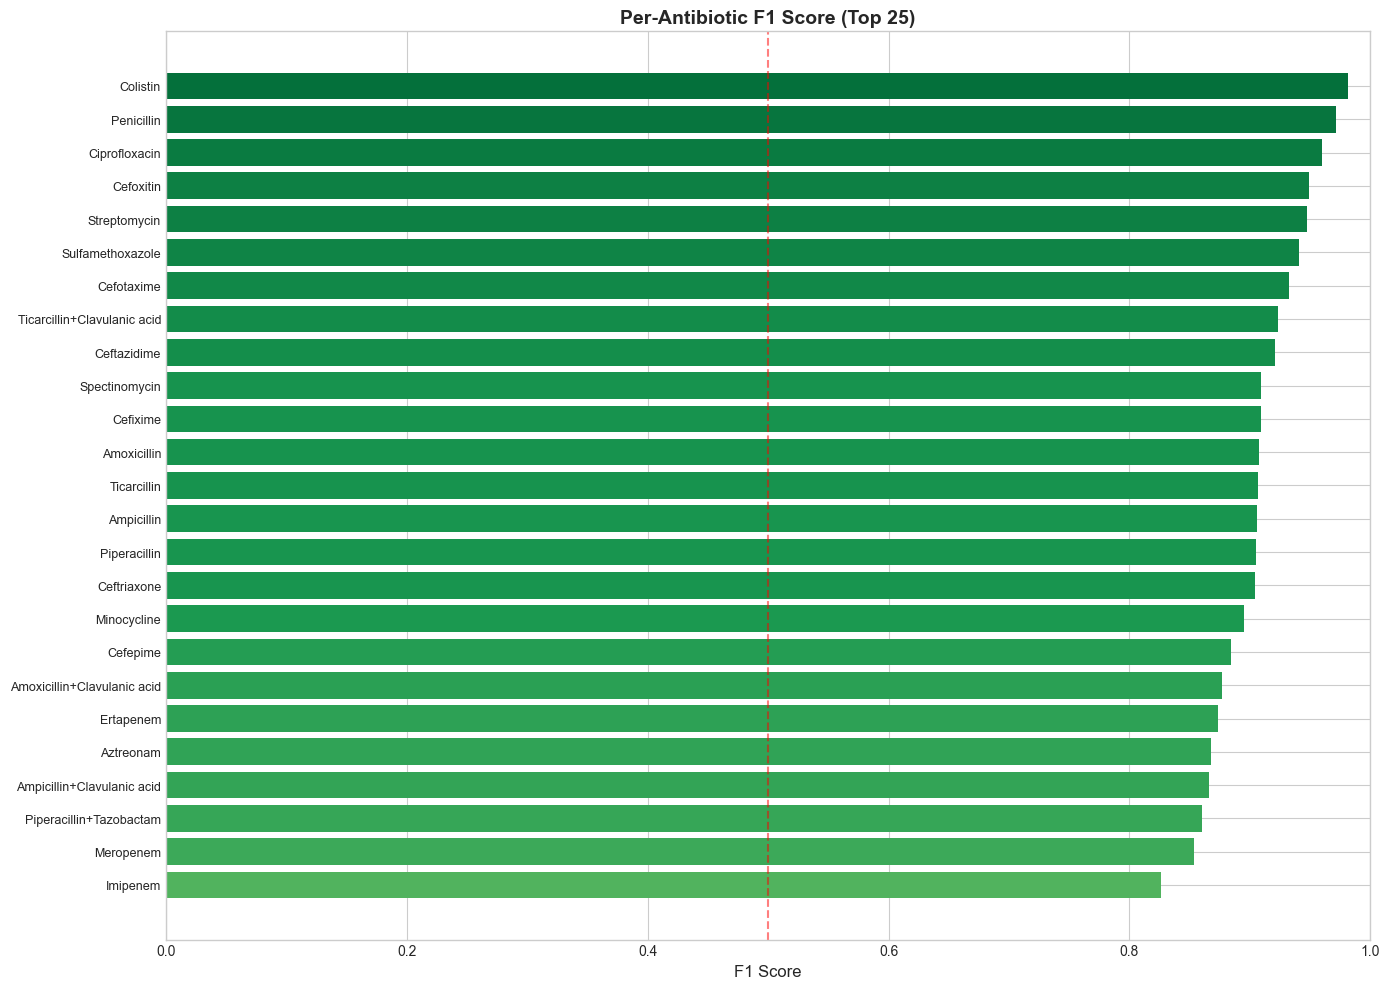

In [39]:
# Per-antibiotic performance (top 20)
per_ab_f1 = f1_score(y_ab_test, y_ab_pred, average=None, zero_division=0)

# Get antibiotics with enough test samples
test_counts = y_ab_test.sum(axis=0)
valid_idx = np.where(test_counts >= 5)[0]

fig, ax = plt.subplots(figsize=(14, 10))

# Sort by F1 score
sorted_idx = valid_idx[np.argsort(per_ab_f1[valid_idx])[::-1]][:25]

colors = plt.cm.RdYlGn(per_ab_f1[sorted_idx])
bars = ax.barh(range(len(sorted_idx)), per_ab_f1[sorted_idx], color=colors)
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([ab_classes[i] for i in sorted_idx], fontsize=9)
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_title('Per-Antibiotic F1 Score (Top 25)', fontsize=14, fontweight='bold')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
ax.invert_yaxis()
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

## Summary

### Key Findings:

1. **Dataset Size**: ResFinder contains 3,212 resistance genes across 17 drug classes

2. **Drug Class Distribution**: Dominated by beta-lactam (63%), followed by aminoglycoside, macrolide, and tetracycline

3. **Resistance Mechanisms**: Enzymatic modification is the most common mechanism (covering 95% of genes)

4. **Sequence Characteristics**: 
   - Average gene length: ~930 bp
   - GC content varies by drug class (40-60%)

5. **Model Performance**:
   - Drug class prediction: High accuracy achievable with k-mer features
   - Mechanism prediction: Imbalanced classes affect performance
   - Antibiotic prediction: Multi-label task shows varying performance across antibiotics

### Next Steps:
- Train deep learning models (CNN for sequence patterns)
- Use protein-level features for genes encoding enzymes
- Integrate with CARD and PATRIC for comprehensive AMR prediction
- Handle class imbalance with oversampling or class weights